In [1]:
import torch
import torch.nn as nn

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io
import numpy as np

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [2]:
df = pd.read_parquet("data/train-00000-of-00008-26f523e9bdcc2b9a.parquet")

In [3]:
sample = df.iloc[4227]

image_bytes = sample['image']['bytes']
image = Image.open(io.BytesIO(image_bytes))

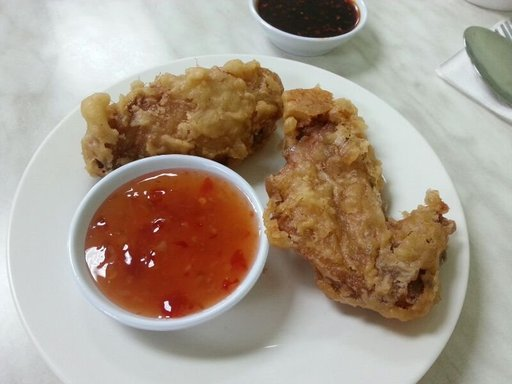

In [4]:
image

In [5]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
class FoodDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ----- Image Bytes → PIL -----
        image_bytes = row["image"]["bytes"]
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        # ----- Transform -----
        if self.transform:
            image = self.transform(image)
        
        return image

In [7]:
dataset = FoodDataset(df, transform=transform)

In [8]:
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

In [9]:
class PatchEmbedding(nn.Module):
    
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        
        self.patch_size = patch_size
        
        self.num_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Linear(
            patch_size * patch_size * in_channels,
            embed_dim
        )
        
    def forward(self, x):
        
        B, C, H, W = x.shape
        
        # ---- Image → patches ----
        x = x.unfold(2, self.patch_size, self.patch_size)
        x = x.unfold(3, self.patch_size, self.patch_size)
        
        # shape: B, C, num_patch_h, num_patch_w, P, P
        
        x = x.contiguous().view(B, C, -1, self.patch_size, self.patch_size)
        
        x = x.permute(0, 2, 1, 3, 4)
        
        # shape: B, num_patches, C, P, P
        
        x = x.flatten(2)
        
        # shape: B, num_patches, patch_dim
        
        x = self.proj(x)
        
        return x

In [10]:
patch_embed = PatchEmbedding()

In [11]:
batch = next(iter(dataloader))

print(batch.shape)

torch.Size([4, 3, 224, 224])


In [12]:
tokens = patch_embed(batch)

In [13]:
tokens.shape

torch.Size([4, 196, 768])

In [14]:
def random_masking(x, mask_ratio=0.75):
    
    """
    x: [B, N, D]
    """
    
    B, N, D = x.shape
    
    len_keep = int(N * (1 - mask_ratio))
    
    # ---- random noise generate ----
    noise = torch.rand(B, N, device=x.device)
    
    # ---- shuffle indices ----
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    
    # ---- keep first tokens ----
    ids_keep = ids_shuffle[:, :len_keep]
    
    x_masked = torch.gather(
        x,
        dim=1,
        index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
    )
    
    # ---- create mask ----
    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    
    # unshuffle mask
    mask = torch.gather(mask, dim=1, index=ids_restore)
    
    return x_masked, mask, ids_restore

In [15]:
visible_tokens, mask, ids_restore = random_masking(tokens)

In [16]:
from feed_forward_nn import feedforward
from positional_encoding import Positional_Encoding
from multihead_attention import MultiHeadAttention

In [17]:
d_model = 768  # main model dimension
num_heads = 8  # number of heads
d_ff = 2048    # feedforward hidden dimension
seq_len = 128  # max input length
vocab_size = 30000

In [18]:
pos_encoding = Positional_Encoding(seq_len, d_model)

In [19]:
visible_tokens = pos_encoding(visible_tokens)

In [20]:
class Encoder_block(nn.Module):
    def __init__(self, d_model, d_ff, num_heads, dropout=0.1):
        super().__init__()
        self.ffn = feedforward(d_model, d_ff)
        self.multi_att = MultiHeadAttention(d_model, num_heads) #d_model >> embed_dim
        self.norm_layer1 = nn.LayerNorm(d_model)
        self.norm_layer2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Multi-Head Self Attention
        mha_out, attn = self.multi_att(x, mask)

        # first Add & Norm (Residual connection)
        residual_1 = x + self.dropout(mha_out) 
        norm_layer1_out = self.norm_layer1(residual_1)

        # Feed Forward Network
        ffn_out = self.ffn(norm_layer1_out)

        # second Add & Norm (Residual connection)
        residual_2 = norm_layer1_out + self.dropout(ffn_out)
        norm_layer2_out = self.norm_layer2(residual_2)

        return norm_layer2_out, attn

In [21]:
class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, d_ff, num_heads):
        super().__init__()

        self.layers = nn.ModuleList([
            Encoder_block(d_model, d_ff, num_heads)
            for _ in range(num_layers)
        ])

    def forward(self, x):

        for layer in self.layers:
            x, _ = layer(x)

        return x

In [22]:
encoder = TransformerEncoder(num_layers=8, d_model=768, d_ff=2048, num_heads=8)

In [23]:
latent = encoder(visible_tokens)

In [24]:
latent

tensor([[[-0.1133,  0.1582,  0.1487,  ...,  0.3860, -0.2793,  0.2223],
         [-0.5774, -0.2504,  0.5576,  ...,  0.8015,  0.3017, -1.3349],
         [-0.2965, -1.5660, -0.2210,  ...,  0.1940, -0.3224,  0.3962],
         ...,
         [ 0.4923, -0.7238, -0.0590,  ...,  0.7988,  0.0353,  0.0109],
         [-0.1213, -0.9493, -0.0922,  ...,  0.5808,  0.2603,  0.2696],
         [-1.2572, -1.2936,  0.3257,  ...,  1.1915,  0.9722, -0.2408]],

        [[-1.1594, -0.1283, -0.8954,  ...,  0.2226,  0.0945,  1.2611],
         [-0.5317,  0.4480, -0.2498,  ...,  0.2380, -0.3521,  0.5660],
         [ 0.4848, -0.9925, -0.1925,  ..., -0.1982, -1.4179,  0.9953],
         ...,
         [ 0.2400, -1.6483, -0.5141,  ...,  0.8457,  0.3646,  1.2655],
         [ 0.2995, -1.3066,  0.8618,  ...,  0.5478,  0.0648,  1.6649],
         [ 0.0412, -0.9203, -0.1843,  ...,  1.0428,  0.3284,  0.8356]],

        [[-0.5711, -0.0738, -0.4561,  ...,  0.7986,  0.0306,  0.0517],
         [-0.7994, -0.6696, -0.2509,  ...,  0

In [25]:
latent.shape

torch.Size([4, 49, 768])

In [26]:
def insert_mask_tokens(x, ids_restore, mask_token):
    
    B, N_visible, D = x.shape
    N_full = ids_restore.shape[1]
    
    # ---- create mask tokens ----
    mask_tokens = mask_token.repeat(B, N_full - N_visible, 1)
    
    # ---- concatenate visible + mask ----
    x_ = torch.cat([x, mask_tokens], dim=1)
    
    # ---- restore original order ----
    x_full = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1,1,D))
    
    return x_full

In [27]:
mask_token = nn.Parameter(torch.zeros(1, 1, 768))

In [28]:
decoder_input = insert_mask_tokens(latent, ids_restore, mask_token)

In [29]:
decoder_input.shape

torch.Size([4, 196, 768])

In [30]:
class MAE_Decoder_Block(nn.Module):

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = feedforward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # ---- Self Attention ----
        attn_out, _ = self.attn(x)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)

        # ---- Feed Forward ----
        ffn_out = self.ffn(x)
        x = x + self.dropout(ffn_out)
        x = self.norm2(x)

        return x

In [43]:
class MAEDecoder(nn.Module):
    def __init__(self, embed_dim=768, depth=4, num_heads=8, d_ff=2048, patch_dim=768):
        
        super().__init__()

        # self.pos_embed = nn.Parameter(torch.zeros(1, 196, embed_dim))
        self.pos_embed = Positional_Encoding(196, d_model)

        self.blocks = nn.ModuleList([
            MAE_Decoder_Block(embed_dim, num_heads, d_ff)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, patch_dim)

    def forward(self, x):

        x = self.pos_embed(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        x = self.head(x)

        return x

In [44]:
decoder = MAEDecoder()

In [45]:
pred = decoder(decoder_input)

In [47]:
pred.shape

torch.Size([4, 196, 768])

In [48]:
def patchify(images, patch_size=16):
    
    B, C, H, W = images.shape
    
    num_patches = H // patch_size
    
    patches = images.unfold(2, patch_size, patch_size)\
                    .unfold(3, patch_size, patch_size)
    
    patches = patches.contiguous().view(
        B, C, -1, patch_size, patch_size
    )
    
    patches = patches.permute(0, 2, 1, 3, 4)
    
    patches = patches.flatten(2)
    
    return patches

In [50]:
target = patchify(batch)
print(target.shape)

torch.Size([4, 196, 768])


In [51]:
loss = (pred - target) ** 2
loss = loss.mean(dim=-1)

loss = (loss * mask).sum() / mask.sum()

In [52]:
loss

tensor(1.6696, grad_fn=<DivBackward0>)

In [53]:
mask.shape

torch.Size([4, 196])

In [54]:
print(pred.shape)
print(target.shape)
print(mask.shape)

torch.Size([4, 196, 768])
torch.Size([4, 196, 768])
torch.Size([4, 196])
